# **Introduction**

This notebook presents a **similarity-based virtual screening** workflow to identify compounds structurally related to the reference inhibitor **AZ191**, which is known to target **DYRK1B**.

The goal of this workflow is to filter a blind chemical dataset and identify the most structurally similar and drug-like compounds that may potentially interact with **DYRK1B**.

The screening pipeline combines chemical similarity searching, drug-likeness filtering, and diversity analysis to obtain a curated subset of compounds suitable for further structure-based studies such as molecular docking.

# **ENVIRONMENT SETUP**

In [1]:
# Install RDKit and import required libraries
# Install RDKit for Colab
!pip install rdkit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, Lipinski, Draw
from rdkit.ML.Cluster import Butina

sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 66.4 MB/s eta 0:00:00


# **Data Loading and Cleaning**

The first step in the workflow involves loading the chemical dataset containing SMILES representations of molecules.

During preprocessing:
SMILES strings are converted into RDKit molecular objects.

Invalid or unparsable SMILES entries are removed.
Duplicate molecules are filtered to avoid redundancy in the dataset.
This step ensures that only chemically valid and unique molecules proceed to the subsequent analysis.

In [8]:
df = pd.read_csv('blind_set.csv')

# Convert SMILES to Mol objects
def smiles_to_mol(smiles):
    return Chem.MolFromSmiles(smiles)

df["Mol"] = df["smiles"].apply(smiles_to_mol)

# Remove invalid SMILES
df = df[df["Mol"].notnull()].copy()

# Remove duplicates by canonical SMILES
df["canSMILES"] = df["Mol"].apply(Chem.MolToSmiles)
df.drop_duplicates(subset="canSMILES", inplace=True)

print("Number of valid, unique molecules:", len(df))

Number of valid, unique molecules: 3365


In [5]:
%%capture
import pandas as pd
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

# Load CSV
data = pd.read_csv("blind_set.csv")

# Function to standardize molecule
def standardize_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol = rdMolStandardize.Cleanup(mol)   # Standard cleanup
        mol = rdMolStandardize.FragmentParent(mol)  # Remove salts
        return Chem.MolToSmiles(mol)
    return None

# Apply standardization
data['canonical_smiles'] = data['smiles'].apply(standardize_molecule)

# Remove failed rows
data = data.dropna(subset=['canonical_smiles'])

# Save file
data.to_csv("blind_set_labelled_standardized.csv", index=False)

# **Morgan Fingerprint Generation**

To represent molecular structures numerically, Morgan fingerprints (ECFP) are generated using RDKit.
Morgan fingerprints encode molecular topology by describing the local chemical environment of atoms within a defined radius. In this workflow:

**Radius = 2**

**Fingerprint size = 2048 bits**

These fingerprints provide a compact and efficient representation of molecules that enables rapid similarity comparisons across large compound libraries.

In [6]:
%%capture
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

# Load your DataFrame with SMILES data (corrected filename)
data = pd.read_csv("blind_set_labelled_standardized.csv")

# Add a 'molecule' column based on 'canonical_smiles'
data['molecule'] = data['canonical_smiles'].apply(Chem.MolFromSmiles)

# Drop rows where molecule creation failed (i.e., SMILES could not be parsed)
data = data.dropna(subset=['molecule'])

# Calculate Morgan fingerprints with depth of 4
num_bits = 2048  # Number of bits in the fingerprint
fingerprints = []

for mol in data['molecule']:
    # Since we dropped rows with None molecules, mol will always be valid here
    fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=num_bits)
    fingerprint = list(fingerprint.ToBitString())
    fingerprints.append(fingerprint)

# Convert the list of fingerprints to a DataFrame
fingerprint_df = pd.DataFrame(fingerprints, columns=[f'Morgan_{i}' for i in range(num_bits)])

# Concatenate the original DataFrame with the fingerprint DataFrame
# Reset indices to ensure correct alignment after dropping rows
data = pd.concat([data.reset_index(drop=True), fingerprint_df.reset_index(drop=True)], axis=1)

# Save the DataFrame with Morgan fingerprints to a new CSV file (corrected filename)
data.to_csv("blind_set_with_morgan_fingerprints.csv", index=None)

In [11]:
# 3. MORGAN FINGERPRINT GENERATION (ECFP4)

def mol_to_fingerprint(mol, radius=2, nBits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

df["Fingerprint"] = df["Mol"].apply(mol_to_fingerprint)

# 4. REFERENCE MOLECULE

REFERENCE_SMILES = "CN1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=CC(=N3)C4=CN(C5=C4C=CN=C5)C)OC" # Placeholder SMILES, replace with your reference molecule's SMILES
ref_mol = Chem.MolFromSmiles(REFERENCE_SMILES)
ref_fp = mol_to_fingerprint(ref_mol)

print("Reference molecule successfully loaded.")

Reference molecule successfully loaded.


[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerator
[20:31:16] DEPRECATION WARNING: please use MorganGenerat

# **Similarity Searching Using Tanimoto Similarity**

Structural similarity between molecules is quantified using the Tanimoto similarity.

Each compound in the dataset is compared against the reference ligand AZ191, and a similarity score ranging from 0 to 1 is calculated:

**1 indicates identical fingerprints**

**0 indicates no shared features**

Compounds are then ranked based on their similarity scores, allowing the identification of molecules that are most structurally related to the reference inhibitor.

In [12]:
# 5. TANIMOTO SIMILARITY SEARCH
def tanimoto(fp1, fp2):
    return DataStructs.TanimotoSimilarity(fp1, fp2)

df["Similarity"] = df["Fingerprint"].apply(lambda fp: tanimoto(ref_fp, fp))

df.sort_values("Similarity", ascending=False, inplace=True)
print(df[["smiles", "Similarity"]].head())

                                                 smiles  Similarity
125   COC1=CC=CC=C1C1=CC=NC(NC(C)C2=NN(C3=CC=CC=C3)C...    0.285714
3255  COC(=O)C1=CC(C(=O)N2CCN(C3=NC=CC(C4=CSC=C4)=N3...    0.268041
200   CC1=CC=CN=C1CC(=O)NC(C1=NC(C2=CN(C)C3=CC=CC=C2...    0.260417
1257              CN1N=C(C2=CC3=CC=CN=C3N2)C2=CC=NC=C21    0.253165
3303  CN1CCCN(C2=CC=C(NC(=O)C3=CSC(C4=CC=CN=C4)=N3)C...    0.252747


# **Drug-Likeness Filtering (Lipinski Rule of Five)**

To prioritize compounds with favorable pharmacokinetic properties, drug-likeness filtering is applied based on the Lipinski's Rule of Five.
The following molecular descriptors are evaluated:

**Molecular Weight (MW ≤ 500)**

**LogP (≤ 5)**

**Hydrogen Bond Donors (≤ 5)**

**Hydrogen Bond Acceptors (≤ 10)**

Compounds satisfying these criteria are considered more likely to exhibit oral bioavailability and acceptable pharmacological properties.

In [13]:
# 6. MOLECULAR DESCRIPTORS

def compute_descriptors(mol):
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotB": Lipinski.NumRotatableBonds(mol),
    }

desc_df = df["Mol"].apply(compute_descriptors).apply(pd.Series)

df = pd.concat([df, desc_df], axis=1)

In [14]:
# 7. LIPINSKI RULE OF FIVE FILTERING

lipinski = (
    (df["MW"] <= 500) &
    (df["LogP"] <= 5) &
    (df["HBD"] <= 5) &
    (df["HBA"] <= 10)
)

df = df[lipinski].copy()
print("After Lipinski filtering:", len(df), "molecules")

After Lipinski filtering: 3362 molecules


In [15]:
# 8. DRUG-LIKENESS FILTERS

drug_like = (
    (df["TPSA"] <= 140) &
    (df["RotB"] <= 10)
)

df = df[drug_like].copy()
print("After additional drug-likeness filtering:", len(df), "molecules")

After additional drug-likeness filtering: 3359 molecules


In [16]:
# 9. RANKING AND SELECTION OF TOP

TOP_100 = 100 # Define the number of top molecules to select

df.sort_values("Similarity", ascending=False, inplace=True)

filtered_all = df.copy()  # Save full filtered list

top_hits = df.head(TOP_100).copy()
top_hits.reset_index(drop=True, inplace=True);

print("Selected top", TOP_100, "molecules.")

Selected top 100 molecules.


# **Visualization**

To better understand the dataset and screening results, several visualization methods are used:

Distribution of Tanimoto similarity scores.

Relationship between **similarity and molecular properties**.

Structural visualization of selected compounds using RDKit.

These plots help in interpreting the chemical space explored during the screening process.

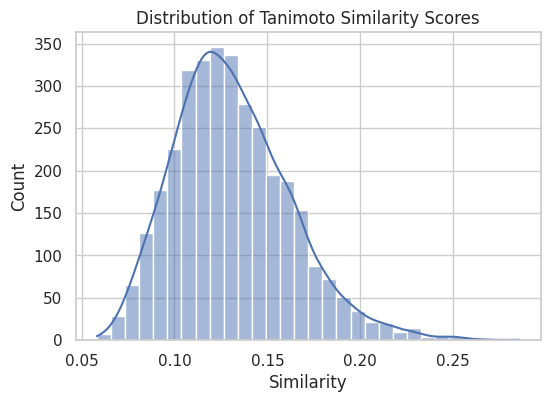

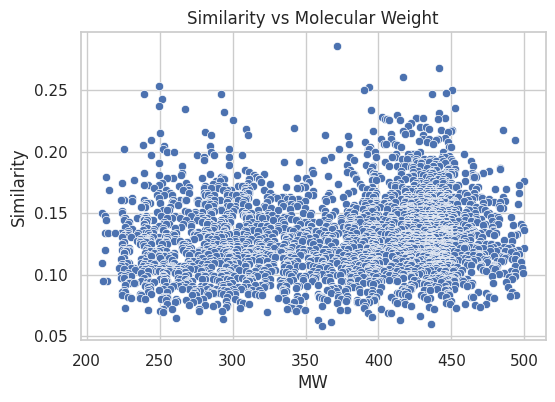

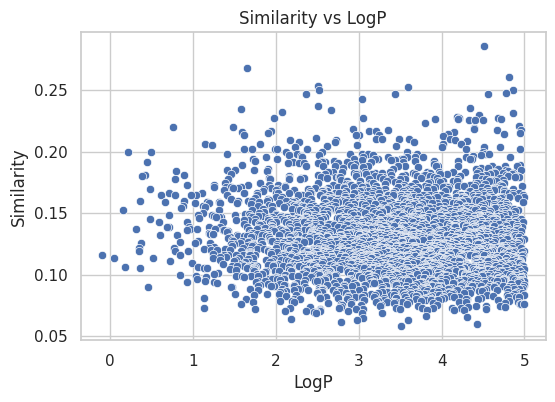

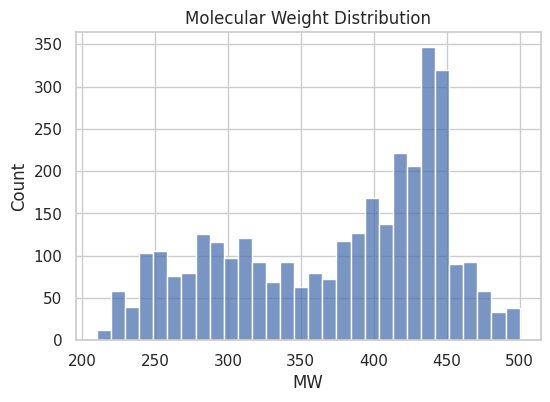

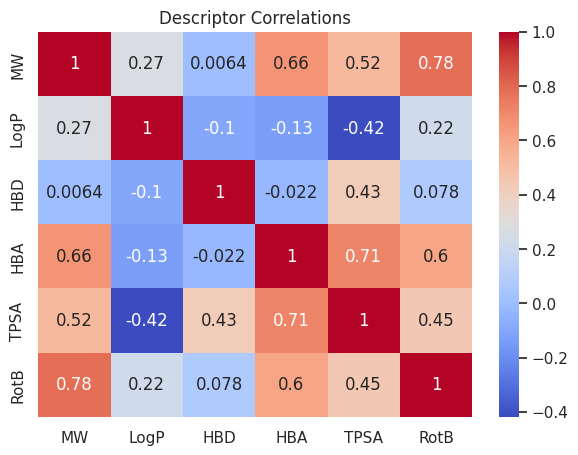

In [17]:
# 10. VISUALIZATION

top_hits=df.nlargest(100, 'Similarity')

# A) Distribution of similarity scores
plt.figure(figsize=(6,4))
sns.histplot(df["Similarity"], bins=30, kde=True)
plt.title("Distribution of Tanimoto Similarity Scores")
plt.show()

# B) Similarity vs Molecular Weight
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="MW", y="Similarity")
plt.title("Similarity vs Molecular Weight")
plt.show()

# C) Similarity vs LogP
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="LogP", y="Similarity")
plt.title("Similarity vs LogP")
plt.show()

# D) MW histogram
plt.figure(figsize=(6,4))
sns.histplot(df["MW"], bins=30)
plt.title("Molecular Weight Distribution")
plt.show()

# E) Descriptor correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[["MW","LogP","HBD","HBA","TPSA","RotB"]].corr(), annot=True, cmap="coolwarm")
plt.title("Descriptor Correlations")
plt.show()

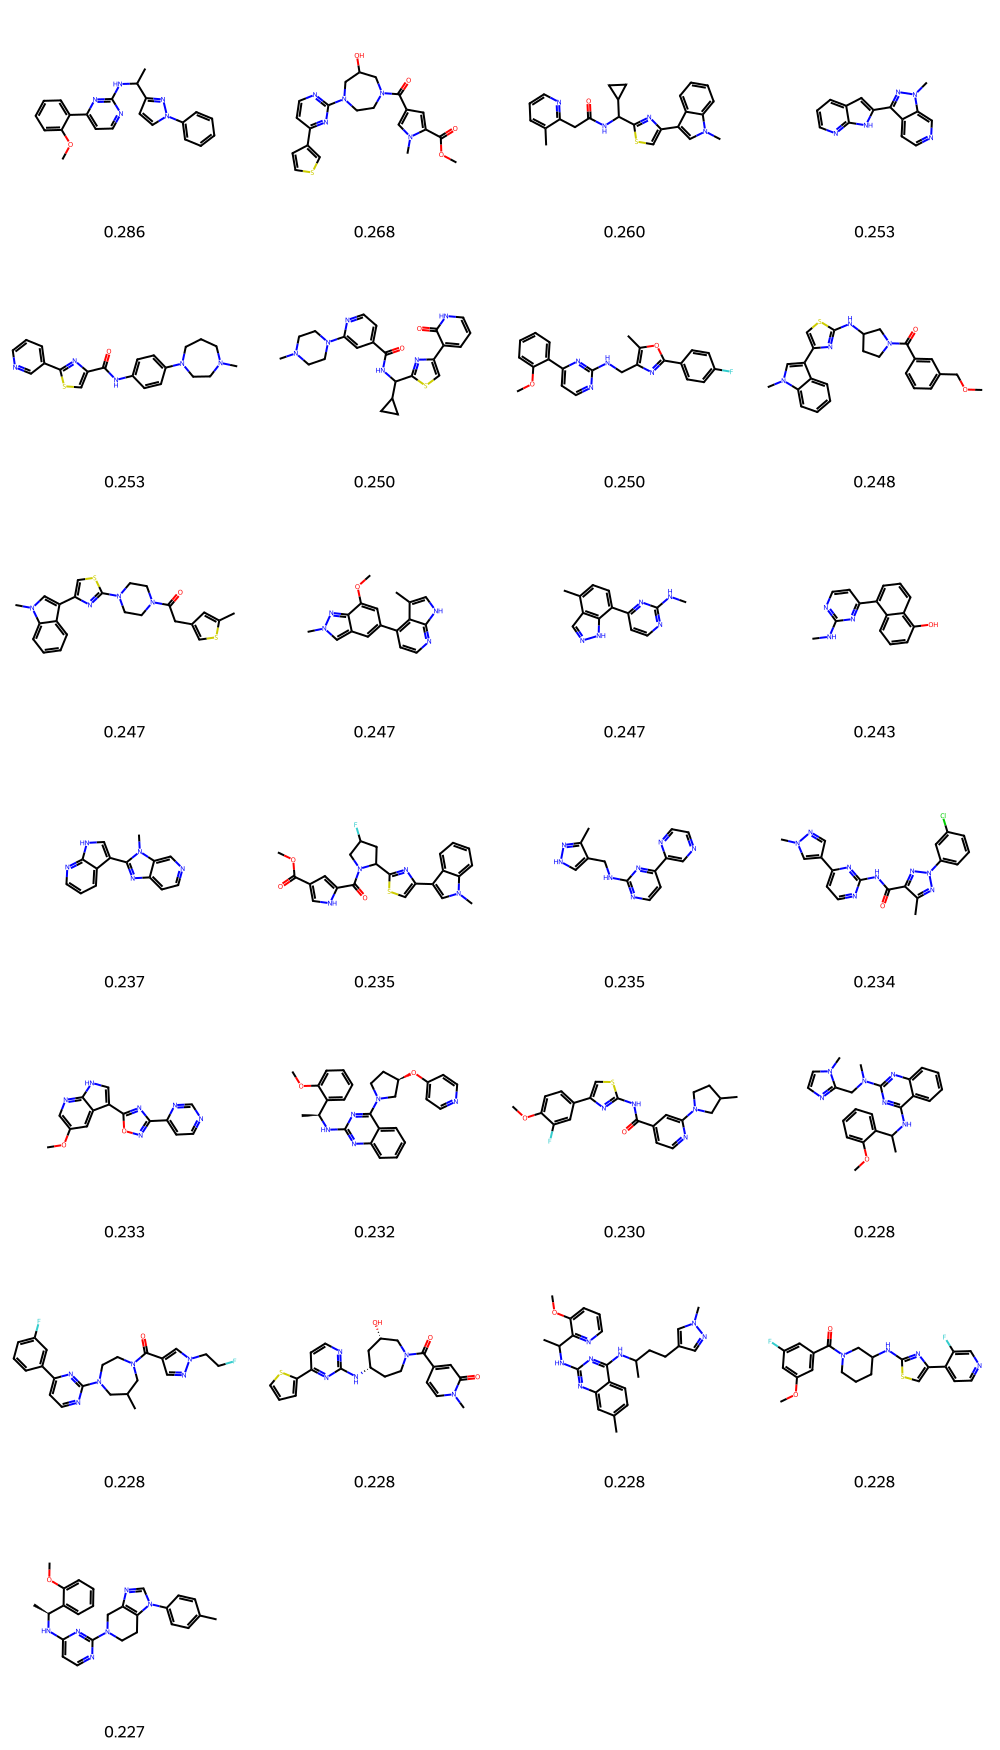

In [18]:
# 11. MOLECULAR VISUALIZATION (TOP 25)

top20 = top_hits.head(25)

legends = [f"{row.Similarity:.3f}" for _, row in top20.iterrows()]
mol_list = top20["Mol"].tolist()

img = Draw.MolsToGridImage(
    mol_list,
    legends=legends,
    molsPerRow=4,
    subImgSize=(250,250)
)

img

# **Diversity Analysis Using Butina Clustering**

After similarity filtering, diversity analysis is performed using Butina clustering.

This clustering algorithm groups molecules based on their pairwise Tanimoto similarity distances.

The purpose of this step is to:

**Identify structural clusters**

**Reduce redundancy among highly similar molecules**

**Ensure chemical diversity among the selected compounds**

This improves the chances of discovering compounds with different scaffolds but similar biological potential.

In [19]:
# 12. DIVERSITY ANALYSIS WITH BUTINA CLUSTERING

fps = list(top_hits["Fingerprint"])

# Compute distance matrix
dists = []
for i in range(len(fps)):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - x for x in sims])

# Clustering at threshold 0.3 (change if desired)
CLUSTER_THRESHOLD = 0.3
clusters = Butina.ClusterData(dists, len(fps), CLUSTER_THRESHOLD, isDistData=True)
print("Number of clusters:", len(clusters))

Number of clusters: 100


# **Loading of Top Hits**

In [22]:
# 13. EXPORT RESULTS

cols_to_export = [
    "smiles", "Similarity", "MW", "LogP", "HBD", "HBA", "TPSA", "RotB"
]

filtered_all[cols_to_export].to_csv("filtered_all_compounds_100.csv", index=False)
top_hits[cols_to_export].to_csv("top_hits_100.csv", index=False)

print("Files saved:")
print(" - filtered_all_compounds_100.csv")
print(" - top_hits_100.csv")

Files saved:
 - filtered_all_compounds_100.csv
 - top_hits_100.csv
